# Módulo 19 — Exercício: Estatística Aplicada

## Efetividade de duas estratégias de ensino (teste A/B com teste Z)

Atividade do curso **EBAC — Profissão: Cientista de Dados**. Uma escola avalia duas estratégias de ensino de matemática para o ensino médio e quer saber se há diferença significativa no desempenho médio dos alunos.

**Hipóteses**
- **H0:** a média das notas na estratégia A é igual à da estratégia B (μB = μA).
- **H1:** a média das notas na estratégia B é **maior** do que na estratégia A (μB > μA).

**Dados:** notas de 50 alunos para cada estratégia (simuladas). Parâmetros populacionais do enunciado: A ~ N(70, 10²) e B ~ N(75, 12²). Como os desvios padrão populacionais são conhecidos, usamos o **teste Z**, com nível de significância α = 0,05.

**Autor:** Talita Luci · [GitHub](https://github.com/TalitaLuci)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Caminhos do projeto (funciona abrindo o notebook a partir de notebooks/ ou da raiz)
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_FILE = PROJECT_ROOT / 'data' / 'raw' / 'notas_estrategias.csv'

ALPHA = 0.05

Os dados são criados a seguir (código do enunciado, sem alterações):

In [2]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


In [3]:
# Conferência: os dados versionados em data/raw/ são exatamente os mesmos gerados acima
dados = pd.read_csv(DATA_FILE)
assert np.allclose(dados.loc[dados['estrategia'] == 'A', 'nota'], amostra_estrategia_A)
assert np.allclose(dados.loc[dados['estrategia'] == 'B', 'nota'], amostra_estrategia_B)
print('OK — CSV idêntico às amostras geradas;', dados.shape[0], 'alunos')

OK — CSV idêntico às amostras geradas; 100 alunos


## 1) O teste é unilateral à direita, à esquerda ou bicaudal? Justifique.

**Resposta: unilateral à direita.**

A hipótese alternativa tem **direção**: H1 afirma que a média de B é **maior** que a de A (μB > μA), e não apenas que as médias são diferentes (o que seria bicaudal). Só nos interessa evidência a favor de B, então toda a probabilidade de erro tipo I (α = 5%) fica concentrada em **uma cauda**.

**A direção da cauda depende de como a estatística é definida:**

| Definição de Z | Se H1 (B melhor) for verdadeira, Z tende a ser… | Região crítica |
|---|---|---|
| Z = (x̄B − x̄A) / EP | **positivo** | **cauda direita** (Z > 1,645) |
| Z = (x̄A − x̄B) / EP | negativo | cauda esquerda (Z < −1,645) |

Os dois testes são equivalentes (mesmo p-valor, mesma decisão), mas o sinal de Z e o lado da região crítica mudam juntos. Para este exercício adotamos **Z = (x̄B − x̄A) / EP**, de modo que o teste fica **à direita**, e o gráfico da questão 4 segue esta mesma convenção.

## 2) Calcule as médias e as variâncias das duas amostras. Quais insights você pode retirar?

In [4]:
resumo = pd.DataFrame({
    'Estratégia A': {
        'n': len(amostra_estrategia_A),
        'média amostral': amostra_estrategia_A.mean(),
        'média populacional': media_estrategia_A,
        'variância amostral': amostra_estrategia_A.var(ddof=1),
        'variância populacional': desvio_padrao_estrategia_A ** 2,
        'desvio padrão amostral': amostra_estrategia_A.std(ddof=1),
        'desvio padrão populacional': desvio_padrao_estrategia_A,
        'erro padrão da média': desvio_padrao_estrategia_A / np.sqrt(len(amostra_estrategia_A)),
    },
    'Estratégia B': {
        'n': len(amostra_estrategia_B),
        'média amostral': amostra_estrategia_B.mean(),
        'média populacional': media_estrategia_B,
        'variância amostral': amostra_estrategia_B.var(ddof=1),
        'variância populacional': desvio_padrao_estrategia_B ** 2,
        'desvio padrão amostral': amostra_estrategia_B.std(ddof=1),
        'desvio padrão populacional': desvio_padrao_estrategia_B,
        'erro padrão da média': desvio_padrao_estrategia_B / np.sqrt(len(amostra_estrategia_B)),
    },
}).T
print('Diferença entre as médias amostrais (B − A): %.2f pontos' % (
    amostra_estrategia_B.mean() - amostra_estrategia_A.mean()))
resumo.round(3).T

Diferença entre as médias amostrais (B − A): 3.34 pontos


,Estratégia A,Estratégia B
n,50.000,50.000
média amostral,71.406,74.749
média populacional,70.000,75.000
variância amostral,129.265,110.470
variância populacional,100.000,144.000
desvio padrão amostral,11.369,10.510
desvio padrão populacional,10.000,12.000
erro padrão da média,1.414,1.697


**Insights**

1. **A diferença observada favorece B**: 74,75 contra 71,41, ou seja, **+3,34 pontos** (a diferença nos parâmetros populacionais é de 5 pontos). Mas uma diferença entre médias, **por si só, não garante significância estatística**: precisamos compará-la com a variabilidade esperada (o erro padrão da diferença, calculado na questão 3).
2. **Médias amostrais ≠ médias populacionais, e isso é normal.** A amostra A ficou 1,41 ponto acima de 70 e a B ficou 0,25 abaixo de 75. Como o erro padrão de cada média é 1,41 (A) e 1,70 (B), esses desvios são **menores ou iguais a 1 erro padrão**, bem dentro do esperado. Cada nova amostra de 50 alunos daria médias um pouco diferentes: é a **variabilidade amostral**.
3. **A ordem das variâncias amostrais está invertida em relação à das populacionais.** Nos parâmetros, B é mais dispersa (σ² = 144 contra 100), mas na amostra ocorre o contrário: A tem variância 129,3 e B tem 110,5. Isso **não é um erro**: com apenas 50 alunos por grupo, a variância amostral também oscila em torno do valor verdadeiro. Por isso o teste Z usa os desvios padrão **populacionais** informados no enunciado, e não os amostrais.
4. **Tamanho da amostra:** quanto maior o n, menor o erro padrão (σ/√n) e mais as estatísticas amostrais se aproximam dos parâmetros. Com n = 50 ainda há bastante ruído, o que afeta a capacidade do teste de detectar diferenças pequenas (ver seção 5).

## 3) Estatística do teste Z, p-valor e decisão sobre H0

Como os σ populacionais são conhecidos:

$$Z = \frac{\bar{x}_B - \bar{x}_A}{\sqrt{\dfrac{\sigma_A^2}{n_A} + \dfrac{\sigma_B^2}{n_B}}}$$

Teste unilateral à direita: **p-valor = P(Z ≥ z observado)** e região crítica **Z > z₁₋α**.

In [5]:
n_A, n_B = len(amostra_estrategia_A), len(amostra_estrategia_B)

diferenca = amostra_estrategia_B.mean() - amostra_estrategia_A.mean()                  # B − A
erro_padrao = np.sqrt(desvio_padrao_estrategia_A**2 / n_A + desvio_padrao_estrategia_B**2 / n_B)

z_obs = diferenca / erro_padrao
p_valor = 1 - stats.norm.cdf(z_obs)         # cauda direita (equivale a stats.norm.sf(z_obs))
z_critico = stats.norm.ppf(1 - ALPHA)       # limite da região crítica à direita

print(f'Diferença das médias (B − A): {diferenca:.4f}')
print(f'Erro padrão da diferença    : {erro_padrao:.4f}')
print(f'Estatística Z               : {z_obs:.4f}')
print(f'Z crítico (α = {ALPHA})       : {z_critico:.4f}')
print(f'p-valor (unilateral direita): {p_valor:.4f}')
print()
if p_valor < ALPHA:
    print('Decisão: p-valor < α  ->  REJEITAMOS H0')
else:
    print('Decisão: p-valor > α  ->  NÃO rejeitamos H0')

Diferença das médias (B − A): 3.3431
Erro padrão da diferença    : 2.2091
Estatística Z               : 1.5133
Z crítico (α = 0.05)       : 1.6449
p-valor (unilateral direita): 0.0651

Decisão: p-valor > α  ->  NÃO rejeitamos H0


**Decisão: não rejeitamos H0.**

- **Z = 1,513**, abaixo do valor crítico **1,645**, ou seja, fora da região crítica.
- **p-valor = 0,0651 > α = 0,05**: se H0 fosse verdadeira, observaríamos uma diferença tão grande a favor de B ou maior em cerca de 6,5% das amostras, o que não é raro o bastante para o nível de 5% exigido.

**Cuidado com a interpretação:** *não rejeitar H0 não prova que as estratégias são iguais*, apenas que **estes dados não bastam** para afirmar que B é melhor. O resultado também é sensível ao nível escolhido: com α = 0,10 a decisão seria rejeitar H0. O p-valor de 0,065 indica evidência fraca a favor de B, e não ausência de efeito (veja a seção 5).

## 4) Gráfico da distribuição da estatística Z

Distribuição normal padrão (distribuição de Z sob H0), com a região crítica **à direita**, consistente com o teste unilateral à direita e com Z = x̄B − x̄A.

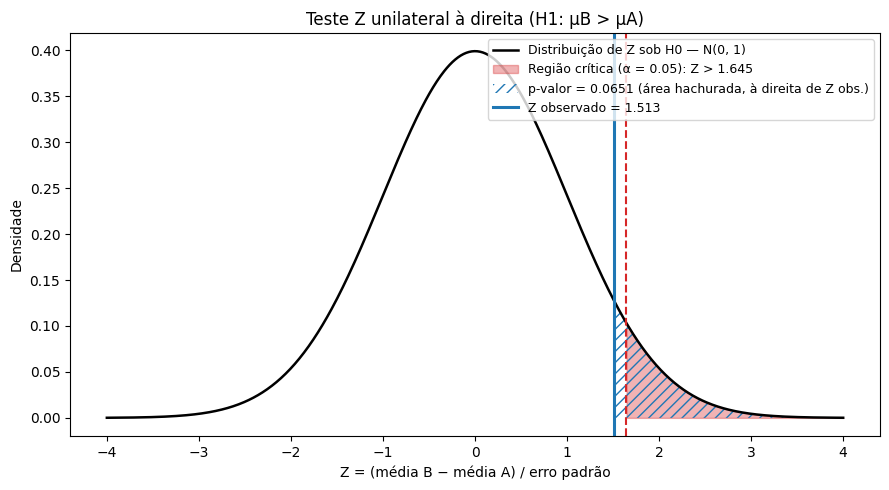

In [6]:
x = np.linspace(-4, 4, 800)
pdf = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, pdf, color='black', lw=1.8, label='Distribuição de Z sob H0 — N(0, 1)')
ax.fill_between(x, pdf, where=x >= z_critico, color='#d62728', alpha=0.35,
                label=f'Região crítica (α = {ALPHA}): Z > {z_critico:.3f}')
ax.fill_between(x, pdf, where=x >= z_obs, facecolor='none', edgecolor='#1f77b4', hatch='///', linewidth=0,
                label=f'p-valor = {p_valor:.4f} (área hachurada, à direita de Z obs.)')
ax.axvline(z_critico, color='#d62728', ls='--', lw=1.5)
ax.axvline(z_obs, color='#1f77b4', lw=2.2, label=f'Z observado = {z_obs:.3f}')
ax.set(title='Teste Z unilateral à direita (H1: μB > μA)',
       xlabel='Z = (média B − média A) / erro padrão', ylabel='Densidade')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

**O que o gráfico mostra**

- A curva é a distribuição de Z **se H0 fosse verdadeira** (N(0,1)). A **região vermelha** (Z > 1,645) concentra os 5% de resultados mais extremos *a favor de B*: se o Z observado caísse ali, rejeitaríamos H0.
- O **Z observado (1,513)**, linha azul, fica **à direita do centro, na direção de B**, mas **antes** do limite crítico. Está na região de **não rejeição**.
- A **área hachurada** à direita do Z observado é o **p-valor (0,0651)**. Como ela é **maior** que a área vermelha (α = 0,05), o p-valor é maior que α, e a decisão de não rejeitar H0 é a mesma tirada de comparar Z com Z crítico. Os dois critérios são equivalentes.
- **Sobre o sinal:** com Z definido como (B − A), um Z **positivo** indica média de B maior que a de A, e a região de rejeição fica na cauda **direita**. Se o Z fosse calculado como (A − B), ele valeria −1,513 e a região crítica ficaria à esquerda; usar a cauda direita com esse valor negativo daria p = 0,935, uma conclusão errada. O sinal e a cauda precisam ser consistentes.

In [7]:
# Verificação do alerta acima: sinal da estatística e cauda devem andar juntos
z_AB = (amostra_estrategia_A.mean() - amostra_estrategia_B.mean()) / erro_padrao
print(f'Z definido como (B − A): {z_obs:+.4f}  -> p (cauda direita)  = {stats.norm.sf(z_obs):.4f}')
print(f'Z definido como (A − B): {z_AB:+.4f}  -> p (cauda esquerda) = {stats.norm.cdf(z_AB):.4f}   (mesma decisão)')
print(f'Z (A − B) com a cauda ERRADA (direita)  -> p = {stats.norm.sf(z_AB):.4f}   (conclusão inválida)')

Z definido como (B − A): +1.5133  -> p (cauda direita)  = 0.0651
Z definido como (A − B): -1.5133  -> p (cauda esquerda) = 0.0651   (mesma decisão)
Z (A − B) com a cauda ERRADA (direita)  -> p = 0.9349   (conclusão inválida)


## 5) Complementos: o que o p-valor sozinho não diz

Esta seção vai além do enunciado. Como os dados foram **simulados** com μB − μA = 5, sabemos que H0 é, de fato, falsa; na prática, não saberíamos disso. A pergunta útil é: **o teste tinha chance razoável de detectar uma diferença dessa ordem com 50 alunos por grupo?**

IC 95% da diferença (B − A): [-0.99, 7.67]
d de Cohen: 0.31  (efeito pequeno a moderado)
Poder com n = 50 por grupo: 73.2%
n por grupo para 80% de poder: 61


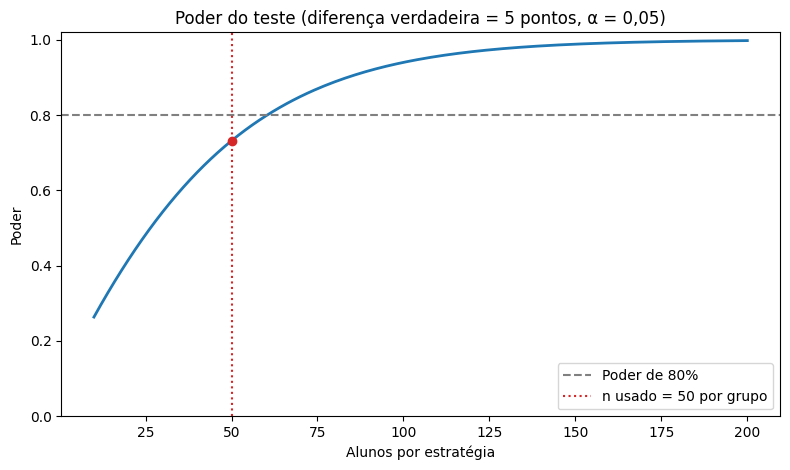

In [8]:
# Intervalo de confiança de 95% da diferença (σ conhecidos) e tamanho do efeito
zc = stats.norm.ppf(0.975)
ic = (diferenca - zc * erro_padrao, diferenca + zc * erro_padrao)
s_comb = np.sqrt(((n_A - 1) * amostra_estrategia_A.var(ddof=1) + (n_B - 1) * amostra_estrategia_B.var(ddof=1)) / (n_A + n_B - 2))
print(f'IC 95% da diferença (B − A): [{ic[0]:.2f}, {ic[1]:.2f}]')
print(f"d de Cohen: {diferenca / s_comb:.2f}  (efeito pequeno a moderado)")

# Poder do teste unilateral à direita para a diferença verdadeira de 5 pontos
dif_verdadeira = media_estrategia_B - media_estrategia_A
se_pop = lambda n: np.sqrt((desvio_padrao_estrategia_A**2 + desvio_padrao_estrategia_B**2) / n)
poder = lambda n: stats.norm.sf(z_critico - dif_verdadeira / se_pop(n))
n_necessario = int(np.ceil((z_critico + stats.norm.ppf(0.80))**2 * (desvio_padrao_estrategia_A**2 + desvio_padrao_estrategia_B**2) / dif_verdadeira**2))
print(f'Poder com n = 50 por grupo: {poder(50):.1%}')
print(f'n por grupo para 80% de poder: {n_necessario}')

n = np.arange(10, 201)
plt.figure(figsize=(8, 4.8))
plt.plot(n, poder(n), lw=2)
plt.axhline(0.8, color='gray', ls='--', label='Poder de 80%')
plt.axvline(50, color='#d62728', ls=':', label='n usado = 50 por grupo')
plt.scatter([50], [poder(50)], color='#d62728', zorder=3)
plt.title('Poder do teste (diferença verdadeira = 5 pontos, α = 0,05)')
plt.xlabel('Alunos por estratégia'); plt.ylabel('Poder'); plt.ylim(0, 1.02); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

**Leitura**

- O **IC de 95% da diferença, [−0,99; 7,67]**, inclui o zero (consistente com a não rejeição de H0), mas também inclui diferenças de vários pontos a favor de B, inclusive os 5 pontos verdadeiros. Os dados são **compatíveis tanto com "nenhum efeito" quanto com um efeito relevante**.
- O **tamanho do efeito observado é pequeno a moderado** (d ≈ 0,31).
- Com 50 alunos por estratégia, o **poder do teste é de ~73%** para detectar uma diferença real de 5 pontos: em cerca de 27% das amostras, o teste *não* a detectaria (erro tipo II). Aqui, a decisão de "não rejeitar" provavelmente é um caso desses. Para ter **80% de poder** seriam necessários **~61 alunos por estratégia**.

**Conclusão geral:** com α = 0,05, **não há evidência estatística suficiente** de que a estratégia B tenha média maior que a A. O resultado, porém, é fronteiriço (p = 0,065) e o teste tem poder limitado; antes de descartar a estratégia B, recomenda-se **repetir o experimento com amostra maior** (≈ 61 ou mais alunos por grupo).